In [19]:
import numpy as np
import tensorflow as tf
from keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt

In [20]:
model = tf.keras.models.load_model('trained_plant_disease_model.keras')

In [22]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 128, 128, 32)      896       
                                                                 
 conv2d_1 (Conv2D)           (None, 126, 126, 32)      9248      
                                                                 
 max_pooling2d (MaxPooling2D  (None, 63, 63, 32)       0         
 )                                                               
                                                                 
 conv2d_2 (Conv2D)           (None, 63, 63, 64)        18496     
                                                                 
 conv2d_3 (Conv2D)           (None, 61, 61, 64)        36928     
                                                                 
 max_pooling2d_1 (MaxPooling  (None, 30, 30, 64)       0         
 2D)                                                    

In [4]:
#Visualising and Performing Prediction on Single image

In [23]:
!pip install opencv-python

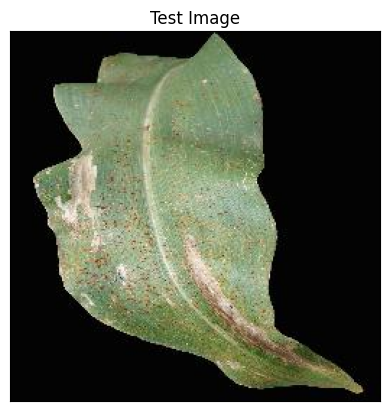

In [24]:
import cv2
image_path = "test/RS_Rust 1563.JPG"
# Reading an image in default mode
img = cv2.imread(image_path)
img = cv2.cvtColor(img,cv2.COLOR_BGR2RGB) #Converting BGR to RGB
# Displaying the image 
plt.imshow(img)
plt.title('Test Image')
plt.xticks([])
plt.yticks([])
plt.show()

In [25]:
#Testing Model

In [26]:
image = tf.keras.preprocessing.image.load_img(image_path,target_size=(128,128))
input_arr = tf.keras.preprocessing.image.img_to_array(image)
input_arr = np.array([input_arr])  # Convert single image to a batch.
print(input_arr.shape)

(1, 128, 128, 3)


In [27]:
predictions = model.predict(input_arr)
predictions,predictions.shape

1/1 [==============================] - 0s 489ms/step


(array([[2.41629073e-28, 5.32030506e-32, 7.62609537e-34, 6.12649805e-35,
         5.78105121e-37, 1.57884847e-37, 1.05942840e-34, 7.31722416e-29,
         1.00000000e+00, 3.03685206e-36, 2.55595636e-31, 0.00000000e+00,
         0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
         1.70172150e-35, 2.08984102e-36, 7.40644897e-35, 7.55087260e-31,
         6.64185590e-36, 0.00000000e+00, 1.27612195e-34, 0.00000000e+00,
         0.00000000e+00, 4.85030115e-37, 1.91505130e-33, 0.00000000e+00,
         0.00000000e+00, 1.22663795e-30, 7.32651262e-25, 0.00000000e+00,
         1.30309375e-35, 0.00000000e+00, 4.97542623e-38, 0.00000000e+00,
         0.00000000e+00, 5.04132735e-35]], dtype=float32),
 (1, 38))

In [28]:
result_index = np.argmax(predictions) #Return index of max element
print(result_index)

8


In [29]:
class_name=['Apple___Apple_scab',
 'Apple___Black_rot',
 'Apple___Cedar_apple_rust',
 'Apple___healthy',
 'Blueberry___healthy',
 'Cherry_(including_sour)___Powdery_mildew',
 'Cherry_(including_sour)___healthy',
 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot',
 'Corn_(maize)___Common_rust_',
 'Corn_(maize)___Northern_Leaf_Blight',
 'Corn_(maize)___healthy',
 'Grape___Black_rot',
 'Grape___Esca_(Black_Measles)',
 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)',
 'Grape___healthy',
 'Orange___Haunglongbing_(Citrus_greening)',
 'Peach___Bacterial_spot',
 'Peach___healthy',
 'Pepper,_bell___Bacterial_spot',
 'Pepper,_bell___healthy',
 'Potato___Early_blight',
 'Potato___Late_blight',
 'Potato___healthy',
 'Raspberry___healthy',
 'Soybean___healthy',
 'Squash___Powdery_mildew',
 'Strawberry___Leaf_scorch',
 'Strawberry___healthy',
 'Tomato___Bacterial_spot',
 'Tomato___Early_blight',
 'Tomato___Late_blight',
 'Tomato___Leaf_Mold',
 'Tomato___Septoria_leaf_spot',
 'Tomato___Spider_mites Two-spotted_spider_mite',
 'Tomato___Target_Spot',
 'Tomato___Tomato_Yellow_Leaf_Curl_Virus',
 'Tomato___Tomato_mosaic_virus',
 'Tomato___healthy']

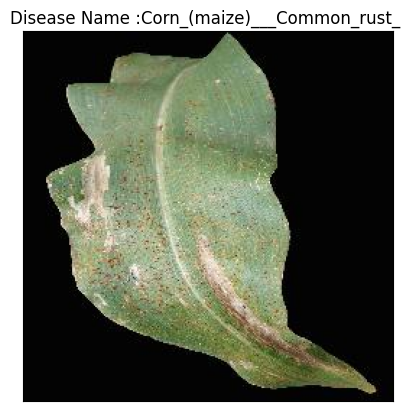

In [32]:
model_prediction = class_name[result_index]
plt.imshow(img)
plt.title(f"Disease Name :{model_prediction} ")
plt.xticks([])
plt.yticks([])
plt.show()

In [33]:
model_prediction

'Corn_(maize)___Common_rust_'

In [34]:
confidence = np.max(predictions) * 100

print("Disease Name:", model_prediction)
print("Confidence:", round(confidence, 2), "%")

Disease Name: Corn_(maize)___Common_rust_
Confidence: 100.0 %


In [35]:
def clean_prediction(label):
    parts = label.split("___")
    crop = parts[0].replace("_", " ")
    disease = parts[1].replace("_", " ") if len(parts) > 1 else "Unknown"
    return crop, disease

crop, disease = clean_prediction(model_prediction)

print("Crop:", crop)
print("Disease:", disease)
print("Confidence:", round(confidence, 2), "%")

Crop: Corn (maize)
Disease: Common rust 
Confidence: 100.0 %


In [36]:
disease_knowledge = {
    "Apple___Apple_scab": {
        "crop": "Apple",
        "disease": "Apple scab",
        "cause": "Fungal disease favored by cool, wet weather.",
        "symptoms": "Olive-green or dark spots on leaves and fruit, leaf curling, fruit cracking.",
        "treatment": "Remove infected leaves/fruits and apply approved fungicide if infection is severe.",
        "prevention": "Prune for airflow, remove fallen leaves, avoid overhead watering.",
        "severity": "Medium-High"
    },
    "Apple___Black_rot": {
        "crop": "Apple",
        "disease": "Black rot",
        "cause": "Fungal infection affecting leaves, fruit, and branches.",
        "symptoms": "Dark circular fruit rot, leaf spots, branch cankers.",
        "treatment": "Remove infected fruit and branches; apply suitable fungicide.",
        "prevention": "Sanitize orchard, prune dead wood, destroy infected debris.",
        "severity": "High"
    },
    "Apple___Cedar_apple_rust": {
        "crop": "Apple",
        "disease": "Cedar apple rust",
        "cause": "Fungal disease spreading between cedar/juniper and apple trees.",
        "symptoms": "Orange-yellow spots on leaves, premature leaf drop.",
        "treatment": "Remove nearby infected cedar galls if possible; apply fungicide early.",
        "prevention": "Use resistant apple varieties and improve spacing.",
        "severity": "Medium"
    },
    "Apple___healthy": {
        "crop": "Apple",
        "disease": "Healthy",
        "cause": "No disease detected.",
        "symptoms": "Leaves appear normal.",
        "treatment": "No treatment required.",
        "prevention": "Continue regular monitoring, pruning, and balanced nutrition.",
        "severity": "None"
    },

    "Blueberry___healthy": {
        "crop": "Blueberry",
        "disease": "Healthy",
        "cause": "No disease detected.",
        "symptoms": "Plant appears healthy.",
        "treatment": "No treatment required.",
        "prevention": "Maintain soil acidity, irrigation, and regular inspection.",
        "severity": "None"
    },

    "Cherry_(including_sour)___Powdery_mildew": {
        "crop": "Cherry",
        "disease": "Powdery mildew",
        "cause": "Fungal disease favored by humid conditions.",
        "symptoms": "White powdery growth on leaves, distorted young leaves.",
        "treatment": "Remove infected leaves and apply approved sulfur/fungicide spray.",
        "prevention": "Improve airflow and avoid dense canopy growth.",
        "severity": "Medium"
    },
    "Cherry_(including_sour)___healthy": {
        "crop": "Cherry",
        "disease": "Healthy",
        "cause": "No disease detected.",
        "symptoms": "Leaves appear normal.",
        "treatment": "No treatment required.",
        "prevention": "Maintain pruning, sanitation, and pest monitoring.",
        "severity": "None"
    },

    "Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot": {
        "crop": "Corn (maize)",
        "disease": "Gray leaf spot",
        "cause": "Fungal disease favored by warm, humid weather.",
        "symptoms": "Long rectangular gray or tan lesions on leaves.",
        "treatment": "Use recommended fungicide when disease pressure is high.",
        "prevention": "Crop rotation, residue management, resistant hybrids.",
        "severity": "High"
    },
    "Corn_(maize)___Common_rust_": {
        "crop": "Corn (maize)",
        "disease": "Common rust",
        "cause": "Fungal disease producing rust-colored pustules.",
        "symptoms": "Small orange-brown pustules on leaf surfaces.",
        "treatment": "Apply suitable fungicide if severe; remove heavily infected leaves.",
        "prevention": "Use resistant varieties and monitor during humid weather.",
        "severity": "Medium"
    },
    "Corn_(maize)___Northern_Leaf_Blight": {
        "crop": "Corn (maize)",
        "disease": "Northern leaf blight",
        "cause": "Fungal disease favored by wet and moderate temperatures.",
        "symptoms": "Long cigar-shaped gray-green lesions on leaves.",
        "treatment": "Apply fungicide during early infection if needed.",
        "prevention": "Use resistant hybrids, rotate crops, manage residue.",
        "severity": "High"
    },
    "Corn_(maize)___healthy": {
        "crop": "Corn (maize)",
        "disease": "Healthy",
        "cause": "No disease detected.",
        "symptoms": "Leaves appear normal.",
        "treatment": "No treatment required.",
        "prevention": "Continue field monitoring and balanced fertilization.",
        "severity": "None"
    },

    "Grape___Black_rot": {
        "crop": "Grape",
        "disease": "Black rot",
        "cause": "Fungal infection common in warm, humid conditions.",
        "symptoms": "Brown leaf spots, black shriveled berries.",
        "treatment": "Remove infected fruit and apply recommended fungicide.",
        "prevention": "Prune vines, improve airflow, remove mummified berries.",
        "severity": "High"
    },
    "Grape___Esca_(Black_Measles)": {
        "crop": "Grape",
        "disease": "Esca / Black measles",
        "cause": "Complex fungal trunk disease.",
        "symptoms": "Tiger-stripe leaf patterns, berry spotting, vine decline.",
        "treatment": "Prune infected wood and remove severely affected vines.",
        "prevention": "Avoid pruning wounds in wet weather and sanitize tools.",
        "severity": "High"
    },
    "Grape___Leaf_blight_(Isariopsis_Leaf_Spot)": {
        "crop": "Grape",
        "disease": "Leaf blight",
        "cause": "Fungal leaf spot disease.",
        "symptoms": "Brown angular leaf spots and drying leaf tissue.",
        "treatment": "Remove infected leaves and apply suitable fungicide.",
        "prevention": "Improve canopy airflow and avoid overhead irrigation.",
        "severity": "Medium"
    },
    "Grape___healthy": {
        "crop": "Grape",
        "disease": "Healthy",
        "cause": "No disease detected.",
        "symptoms": "Leaves appear normal.",
        "treatment": "No treatment required.",
        "prevention": "Maintain pruning, irrigation, and vineyard sanitation.",
        "severity": "None"
    },

    "Orange___Haunglongbing_(Citrus_greening)": {
        "crop": "Orange",
        "disease": "Citrus greening",
        "cause": "Bacterial disease spread by citrus psyllids.",
        "symptoms": "Yellow mottled leaves, bitter small fruits, tree decline.",
        "treatment": "Remove severely infected trees and control psyllid insects.",
        "prevention": "Use disease-free planting material and monitor psyllids.",
        "severity": "Very High"
    },

    "Peach___Bacterial_spot": {
        "crop": "Peach",
        "disease": "Bacterial spot",
        "cause": "Bacterial infection favored by warm, wet conditions.",
        "symptoms": "Small dark leaf spots, shot-hole leaves, fruit lesions.",
        "treatment": "Remove infected parts and use approved copper-based sprays carefully.",
        "prevention": "Use resistant varieties and avoid overhead irrigation.",
        "severity": "Medium-High"
    },
    "Peach___healthy": {
        "crop": "Peach",
        "disease": "Healthy",
        "cause": "No disease detected.",
        "symptoms": "Leaves appear normal.",
        "treatment": "No treatment required.",
        "prevention": "Maintain orchard hygiene and regular monitoring.",
        "severity": "None"
    },

    "Pepper,_bell___Bacterial_spot": {
        "crop": "Bell pepper",
        "disease": "Bacterial spot",
        "cause": "Bacterial disease spread by splashing water and infected seed.",
        "symptoms": "Water-soaked spots on leaves, dark lesions, leaf drop.",
        "treatment": "Remove infected plants and apply approved copper-based treatment.",
        "prevention": "Use clean seeds, avoid overhead watering, rotate crops.",
        "severity": "High"
    },
    "Pepper,_bell___healthy": {
        "crop": "Bell pepper",
        "disease": "Healthy",
        "cause": "No disease detected.",
        "symptoms": "Leaves appear normal.",
        "treatment": "No treatment required.",
        "prevention": "Maintain crop hygiene and regular inspection.",
        "severity": "None"
    },

    "Potato___Early_blight": {
        "crop": "Potato",
        "disease": "Early blight",
        "cause": "Fungal disease common in warm, humid conditions.",
        "symptoms": "Dark concentric ring spots on older leaves.",
        "treatment": "Remove infected leaves and apply suitable fungicide.",
        "prevention": "Crop rotation, avoid water stress, remove plant debris.",
        "severity": "Medium-High"
    },
    "Potato___Late_blight": {
        "crop": "Potato",
        "disease": "Late blight",
        "cause": "Water mold pathogen favored by cool, wet weather.",
        "symptoms": "Dark water-soaked leaf lesions, white mold underside, rapid plant collapse.",
        "treatment": "Remove infected plants and apply recommended fungicide quickly.",
        "prevention": "Use certified seed, avoid overhead watering, monitor weather risk.",
        "severity": "Very High"
    },
    "Potato___healthy": {
        "crop": "Potato",
        "disease": "Healthy",
        "cause": "No disease detected.",
        "symptoms": "Leaves appear normal.",
        "treatment": "No treatment required.",
        "prevention": "Continue monitoring and good field sanitation.",
        "severity": "None"
    },

    "Raspberry___healthy": {
        "crop": "Raspberry",
        "disease": "Healthy",
        "cause": "No disease detected.",
        "symptoms": "Leaves appear normal.",
        "treatment": "No treatment required.",
        "prevention": "Maintain pruning, spacing, and regular monitoring.",
        "severity": "None"
    },

    "Soybean___healthy": {
        "crop": "Soybean",
        "disease": "Healthy",
        "cause": "No disease detected.",
        "symptoms": "Leaves appear normal.",
        "treatment": "No treatment required.",
        "prevention": "Monitor for pests, maintain soil fertility, rotate crops.",
        "severity": "None"
    },

    "Squash___Powdery_mildew": {
        "crop": "Squash",
        "disease": "Powdery mildew",
        "cause": "Fungal disease favored by warm, humid conditions.",
        "symptoms": "White powdery patches on leaves and stems.",
        "treatment": "Remove affected leaves and apply approved fungicide or sulfur spray.",
        "prevention": "Improve airflow, avoid crowding, use resistant varieties.",
        "severity": "Medium"
    },

    "Strawberry___Leaf_scorch": {
        "crop": "Strawberry",
        "disease": "Leaf scorch",
        "cause": "Fungal disease affecting strawberry foliage.",
        "symptoms": "Purple-red leaf spots, scorched leaf edges, reduced plant vigor.",
        "treatment": "Remove infected leaves and apply recommended fungicide.",
        "prevention": "Use clean plants, improve airflow, avoid wet foliage.",
        "severity": "Medium"
    },
    "Strawberry___healthy": {
        "crop": "Strawberry",
        "disease": "Healthy",
        "cause": "No disease detected.",
        "symptoms": "Leaves appear normal.",
        "treatment": "No treatment required.",
        "prevention": "Maintain clean beds and avoid excess moisture.",
        "severity": "None"
    },

    "Tomato___Bacterial_spot": {
        "crop": "Tomato",
        "disease": "Bacterial spot",
        "cause": "Bacterial infection spread by splashing water and infected seed.",
        "symptoms": "Small dark leaf spots, yellowing, fruit lesions.",
        "treatment": "Remove infected leaves and use approved copper-based treatment.",
        "prevention": "Use disease-free seed, avoid overhead irrigation, rotate crops.",
        "severity": "High"
    },
    "Tomato___Early_blight": {
        "crop": "Tomato",
        "disease": "Early blight",
        "cause": "Fungal disease affecting older leaves first.",
        "symptoms": "Brown spots with concentric rings, yellowing leaves.",
        "treatment": "Remove infected leaves and apply suitable fungicide.",
        "prevention": "Mulch soil, rotate crops, avoid leaf wetness.",
        "severity": "Medium-High"
    },
    "Tomato___Late_blight": {
        "crop": "Tomato",
        "disease": "Late blight",
        "cause": "Water mold pathogen favored by cool, wet weather.",
        "symptoms": "Dark water-soaked leaf patches, white mold underside, rapid spread.",
        "treatment": "Remove infected plants and apply recommended fungicide quickly.",
        "prevention": "Avoid overhead watering, improve airflow, monitor humid weather.",
        "severity": "Very High"
    },
    "Tomato___Leaf_Mold": {
        "crop": "Tomato",
        "disease": "Leaf mold",
        "cause": "Fungal disease common in humid greenhouse or dense canopy conditions.",
        "symptoms": "Yellow patches on upper leaves, olive mold underside.",
        "treatment": "Remove infected leaves and improve ventilation.",
        "prevention": "Reduce humidity, increase spacing, avoid wet leaves.",
        "severity": "Medium"
    },
    "Tomato___Septoria_leaf_spot": {
        "crop": "Tomato",
        "disease": "Septoria leaf spot",
        "cause": "Fungal disease spread by rain splash and infected debris.",
        "symptoms": "Small circular spots with gray centers and dark edges.",
        "treatment": "Remove infected lower leaves and apply approved fungicide.",
        "prevention": "Mulch soil, rotate crops, remove plant debris.",
        "severity": "Medium-High"
    },
    "Tomato___Spider_mites Two-spotted_spider_mite": {
        "crop": "Tomato",
        "disease": "Two-spotted spider mite damage",
        "cause": "Mite infestation, common in hot and dry conditions.",
        "symptoms": "Tiny yellow speckles, webbing, leaf bronzing.",
        "treatment": "Spray water to reduce mites and apply suitable miticide if severe.",
        "prevention": "Avoid dusty dry conditions and monitor undersides of leaves.",
        "severity": "Medium"
    },
    "Tomato___Target_Spot": {
        "crop": "Tomato",
        "disease": "Target spot",
        "cause": "Fungal disease favored by warm, humid weather.",
        "symptoms": "Brown circular lesions with target-like rings.",
        "treatment": "Remove infected leaves and apply suitable fungicide.",
        "prevention": "Improve airflow, avoid overhead watering, rotate crops.",
        "severity": "Medium-High"
    },
    "Tomato___Tomato_Yellow_Leaf_Curl_Virus": {
        "crop": "Tomato",
        "disease": "Tomato yellow leaf curl virus",
        "cause": "Viral disease spread mainly by whiteflies.",
        "symptoms": "Yellow curled leaves, stunted growth, reduced fruiting.",
        "treatment": "Remove infected plants and control whiteflies.",
        "prevention": "Use resistant varieties, insect nets, and whitefly management.",
        "severity": "Very High"
    },
    "Tomato___Tomato_mosaic_virus": {
        "crop": "Tomato",
        "disease": "Tomato mosaic virus",
        "cause": "Viral disease spread through contact, tools, and infected material.",
        "symptoms": "Mottled leaves, distorted growth, reduced fruit quality.",
        "treatment": "Remove infected plants; disinfect tools and hands.",
        "prevention": "Use virus-free seed, sanitize tools, avoid tobacco contamination.",
        "severity": "High"
    },
    "Tomato___healthy": {
        "crop": "Tomato",
        "disease": "Healthy",
        "cause": "No disease detected.",
        "symptoms": "Leaves appear normal.",
        "treatment": "No treatment required.",
        "prevention": "Continue regular watering, nutrition, and pest monitoring.",
        "severity": "None"
    }
}

In [37]:
info = disease_knowledge.get(model_prediction)

print("Crop:", crop)
print("Disease:", disease)
print("Confidence:", round(confidence, 2), "%")

if info:
    print("Cause:", info["cause"])
    print("Symptoms:", info["symptoms"])
    print("Treatment:", info["treatment"])
    print("Prevention:", info["prevention"])
    print("Severity:", info["severity"])
else:
    print("Recommendation not found for:", model_prediction)

Crop: Corn (maize)
Disease: Common rust 
Confidence: 100.0 %
Cause: Fungal disease producing rust-colored pustules.
Symptoms: Small orange-brown pustules on leaf surfaces.
Treatment: Apply suitable fungicide if severe; remove heavily infected leaves.
Prevention: Use resistant varieties and monitor during humid weather.
Severity: Medium


In [38]:
def predict_disease(image_path):
    img = tf.keras.preprocessing.image.load_img(image_path, target_size=(128, 128))
    img_array = tf.keras.preprocessing.image.img_to_array(img)
    img_array = np.array([img_array])

    predictions = model.predict(img_array)

    result_index = np.argmax(predictions)
    model_prediction = class_name[result_index]
    confidence = np.max(predictions) * 100

    crop, disease = clean_prediction(model_prediction)
    info = disease_knowledge.get(model_prediction, {})

    result = {
        "crop": crop,
        "disease": disease,
        "confidence": round(confidence, 2),
        "class_name": model_prediction,
        "cause": info.get("cause", "Not available"),
        "symptoms": info.get("symptoms", "Not available"),
        "treatment": info.get("treatment", "Not available"),
        "prevention": info.get("prevention", "Not available"),
        "severity": info.get("severity", "Unknown")
    }

    return result, img

In [39]:
result, img = predict_disease("test/RS_Rust 1563.JPG")

print(result)

1/1 [==============================] - 0s 140ms/step
{'crop': 'Corn (maize)', 'disease': 'Common rust ', 'confidence': 100.0, 'class_name': 'Corn_(maize)___Common_rust_', 'cause': 'Fungal disease producing rust-colored pustules.', 'symptoms': 'Small orange-brown pustules on leaf surfaces.', 'treatment': 'Apply suitable fungicide if severe; remove heavily infected leaves.', 'prevention': 'Use resistant varieties and monitor during humid weather.', 'severity': 'Medium'}


1/1 [==============================] - 0s 61ms/step


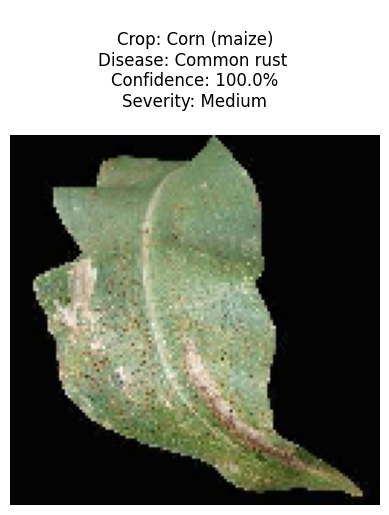


CAUSE:
Fungal disease producing rust-colored pustules.

SYMPTOMS:
Small orange-brown pustules on leaf surfaces.

TREATMENT:
Apply suitable fungicide if severe; remove heavily infected leaves.

PREVENTION:
Use resistant varieties and monitor during humid weather.


In [40]:
result, img = predict_disease("test/RS_Rust 1563.JPG")

plt.imshow(img)
plt.axis("off")
plt.title(
    f"""
Crop: {result['crop']}
Disease: {result['disease']}
Confidence: {result['confidence']}%
Severity: {result['severity']}
"""
)
plt.show()

print("\nCAUSE:")
print(result["cause"])

print("\nSYMPTOMS:")
print(result["symptoms"])

print("\nTREATMENT:")
print(result["treatment"])

print("\nPREVENTION:")
print(result["prevention"])